# Lecture 11 (B09): Physics-informed neural networks

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §7.1-7.4 (PINN foundations), §7.5-7.9 (Economic PDEs (HJB, Black-Scholes))  
**Notebook role:** core  
**Original live-course source:** `lectures/day6/code/04_Cake_Eating_HJB_PINN.ipynb`  
**Author:** Simon Scheidegger  


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 42

_RUN_HP = {
    "smoke":      {"adam_lr": 2e-3, "adam_iters":  400, "batch_sz":  128, "lbfgs_points": 100, "lbfgs_iters": 100, "adam_print_every":  100},
    "teaching":   {"adam_lr": 2e-3, "adam_iters": 2000, "batch_sz":  512, "lbfgs_points": 300, "lbfgs_iters": 300, "adam_print_every":  500},
    "production": {"adam_lr": 2e-3, "adam_iters": 8000, "batch_sz": 1024, "lbfgs_points": 600, "lbfgs_iters": 600, "adam_print_every": 1000},
}
if RUN_MODE not in _RUN_HP:
    raise ValueError(f"RUN_MODE must be one of {list(_RUN_HP)}")
HP = _RUN_HP[RUN_MODE]
print(f"RUN_MODE={RUN_MODE!r}; SEED={SEED}; hyperparameters: {HP}")


# Solving the Cake-Eating HJB Equation with PINNs

In this notebook we solve the **continuous-time consumption-savings (cake-eating) problem** using a
Physics-Informed Neural Network (PINN) built as a **hard-boundary trial solution** with a compact MLP.

The cake-eating problem is one of the simplest dynamic optimization problems in economics:
an agent holds a stock of wealth (the "cake") that earns interest at rate $r$ and must choose
how much to consume at every instant in time so as to maximise lifetime discounted utility.
In continuous time the optimality condition takes the form of a **Hamilton-Jacobi-Bellman (HJB)**
ordinary differential equation for the value function $V(a)$.

This exercise connects directly to the **Deep Equilibrium Nets (DEQNs)** approach introduced
earlier in the course (Chapters 4-6, DEQNs): there we parameterised policy and value functions
with neural networks and trained them to satisfy equilibrium conditions.  Here we do the same
thing, but the equilibrium condition is a PDE (or, in this stationary case, an ODE) that we
enforce through the PINN residual loss.

We will:
1. State the HJB equation and derive its analytical solution.
2. Build a scaled trial-solution network to approximate $V(a)$ while satisfying endpoint values exactly.
3. Train the network by minimising the HJB residual on collocation points.
4. Compare the learned value and policy functions against the closed-form solution.

> **In-class notebook** (Day 6, Block 1 \u2014 PINNs Foundations & Economic Applications, 75 min)

## The Economic Model

An infinitely-lived agent maximises
$$\max_{\{c_t\}} \int_0^\infty e^{-\rho t}\,u(c_t)\,dt, \qquad u(c)=\frac{c^{1-\gamma}}{1-\gamma},$$
subject to the wealth ("cake") evolution
$$\dot a_t = r\,a_t - c_t, \qquad a_0 \text{ given}.$$

**HJB equation.** In the stationary formulation the value function $V(a)$ satisfies
$$\rho\,V(a) = \max_{c}\left\{\frac{c^{1-\gamma}}{1-\gamma} + V'(a)\,(r\,a - c)\right\}.$$

**First-order condition.** Differentiating the right-hand side with respect to $c$ gives
$$c^{-\gamma} = V'(a) \quad\Longrightarrow\quad c^* = \bigl(V'(a)\bigr)^{-1/\gamma}.$$

**Analytical solution.** With CRRA utility one can verify by substitution that
$$V^*(a) = \frac{\kappa^{-\gamma}}{1-\gamma}\,a^{1-\gamma}, \qquad c^*(a)=\kappa\,a,$$
where the marginal propensity to consume is
$$\kappa = \frac{\rho - (1-\gamma)\,r}{\gamma}.$$

**Parameters.** We set $\gamma=2$, $\rho=0.05$, $r=0.03$, giving $\kappa=0.04$.

In [1]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
import random
import os

# ---------- reproducibility (SEED comes from the run-mode cell at the top) ----------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---------- device and dtype ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
print(f"Device: {device}  |  dtype: {dtype}")

plt.rcParams['font.size'] = 13

# torch.compile is wrapped on per-batch steps below for JIT speedups.
# PINN-style losses use torch.autograd.grad with create_graph=True (double
# backward), which the default aot_autograd backend in PyTorch 2.x does not
# yet support. We use backend='eager' and allow dynamo to fall back to eager
# Python whenever it cannot trace a sub-call (e.g. clip_grad_norm_).
import torch._dynamo
torch._dynamo.config.suppress_errors = True


Device: cpu  |  dtype: torch.float64


In [2]:
# ---------- economic parameters ----------
gamma = 2.0          # risk aversion
rho   = 0.05         # discount rate
r     = 0.03         # interest rate
kappa = (rho - (1.0 - gamma) * r) / gamma   # = 0.04

a_min = 0.1          # lower bound of the wealth domain
a_max = 4.0          # upper bound of the wealth domain

print(f"gamma = {gamma},  rho = {rho},  r = {r},  kappa = {kappa}")

# ---------- analytical solutions ----------
V_star = lambda a: (kappa ** (-gamma)) / (1.0 - gamma) * a ** (1.0 - gamma)
c_star = lambda a: kappa * a

gamma = 2.0,  rho = 0.05,  r = 0.03,  kappa = 0.04



## Scaled Trial Solution with Hard Boundary Conditions

For this one-dimensional HJB, a full DGM architecture is more machinery than we need. The previous version trained a large gated network with soft boundary penalties and the boundary loss dominated the objective. Here we use a smaller, scaled MLP inside a **hard-boundary trial solution**:

$$
\hat V(a) = V^*(a_{\min}) + x(a)\{V^*(a_{\max})-V^*(a_{\min})\} + x(a)(1-x(a))S f_\theta(x(a)),
$$
where $x(a)=(a-a_{\min})/(a_{\max}-a_{\min})$ and $S$ is a value-function scale. The endpoints are exact by construction, so the optimizer can focus on the HJB residual. We use Adam for a warm start and then a deterministic double-precision L-BFGS polish, which is the part most sensitive to numerical precision.

In [3]:

class ScaledMLPValue(nn.Module):
    """Hard-boundary trial solution for the 1D cake-eating HJB."""

    def __init__(self, a_min: float, a_max: float, width: int = 64, depth: int = 3):
        super().__init__()
        self.a_min = float(a_min)
        self.a_max = float(a_max)
        self.register_buffer("V_lo", torch.tensor(float(V_star(a_min)), dtype=dtype))
        self.register_buffer("V_hi", torch.tensor(float(V_star(a_max)), dtype=dtype))
        self.register_buffer("V_scale", torch.tensor(abs(float(V_star(a_min))), dtype=dtype))

        layers = []
        d_in = 1
        for _ in range(depth):
            layers += [nn.Linear(d_in, width), nn.Tanh()]
            d_in = width
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, a: torch.Tensor) -> torch.Tensor:
        x = (a - self.a_min) / (self.a_max - self.a_min)
        x_norm = 2.0 * x - 1.0
        linear_boundary = self.V_lo + x * (self.V_hi - self.V_lo)
        correction = self.V_scale * x * (1.0 - x) * self.net(x_norm)
        return linear_boundary + correction


# ---------- instantiate the model ----------
model = ScaledMLPValue(a_min, a_max, width=64, depth=3).to(device=device, dtype=dtype)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")


ScaledMLPValue(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total trainable parameters: 8,513


## PDE Residual

We enforce the HJB equation by penalising its residual at randomly sampled collocation points.
After substituting the FOC $c^* = (V'(a))^{-1/\gamma}$ back into the HJB we obtain the residual
$$\mathcal{R}(a) = \rho\,V(a) - \left[\frac{(c^*)^{1-\gamma}}{1-\gamma} + V'(a)\,(r\,a - c^*)\right].$$

A practical issue is that $V'(a)$ must be **strictly positive** to evaluate
$c^* = (V'(a))^{-1/\gamma}$.  Early in training the network output is essentially random and
$V'(a)$ can easily become negative.  We apply a **softplus safeguard**:
$$\widetilde{V'} = \mathrm{softplus}(V'(a)) + \varepsilon$$
to guarantee positivity without destroying gradients.

In [4]:

def pde_residual(model: nn.Module, a: torch.Tensor):
    """Compute the HJB residual at collocation points *a*."""
    V = model(a)
    V_a = autograd.grad(
        outputs=V, inputs=a,
        grad_outputs=torch.ones_like(V),
        create_graph=True
    )[0]

    # A smooth positivity safeguard keeps gradients alive during the Adam warm start.
    safe_Va = nn.functional.softplus(V_a) + 1e-6  # positivity guard; matches script/deck \varepsilon
    c = safe_Va ** (-1.0 / gamma)
    u_c = c ** (1.0 - gamma) / (1.0 - gamma)
    R = rho * V - (u_c + safe_Va * (r * a - c))
    return R



## Training

Because the trial solution satisfies the two value boundaries exactly, the training loss is just the interior HJB residual. The final L-BFGS step is evaluated on a fixed grid, not on resampled collocation points, so the quasi-Newton line search sees a deterministic double-precision objective.

In [5]:

# ---------- training hyper-parameters (dispatched from RUN_MODE) ----------
adam_lr      = HP["adam_lr"]
adam_iters   = HP["adam_iters"]
batch_sz     = HP["batch_sz"]
lbfgs_points = HP["lbfgs_points"]
lbfgs_iters  = HP["lbfgs_iters"]

optimizer = torch.optim.Adam(model.parameters(), lr=adam_lr)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=[800, 1500], gamma=0.4
)


def sample_interior(n: int) -> torch.Tensor:
    """Sample n uniform random points in [a_min, a_max], with grad enabled."""
    a = torch.rand(n, 1, device=device, dtype=dtype) * (a_max - a_min) + a_min
    a.requires_grad_(True)
    return a


print(f"Boundary values are exact by construction:")
print(f"  model({a_min}) = {model(torch.tensor([[a_min]], device=device, dtype=dtype)).item():.6f}")
print(f"  model({a_max}) = {model(torch.tensor([[a_max]], device=device, dtype=dtype)).item():.6f}")
print(f"Adam warm start: {adam_iters} iterations, batch size {batch_sz}")
print(f"L-BFGS polish : {lbfgs_iters} iterations on {lbfgs_points} fixed collocation points")


Boundary values are exact by construction:
  model(0.1) = -6250.000000
  model(4.0) = -156.250000
Adam warm start: 2000 iterations, batch size 512
L-BFGS polish : 300 iterations on 300 fixed collocation points


In [6]:

# ---------- Adam warm start ----------
loss_history = []

for it in range(1, adam_iters + 1):
    a_int = sample_interior(batch_sz)
    optimizer.zero_grad()
    R = pde_residual(model, a_int)
    loss = torch.mean(R ** 2)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 50.0)
    optimizer.step()
    scheduler.step()
    loss_history.append(loss.item())

    if it % HP["adam_print_every"] == 0 or it == 1:
        print(f"Adam {it:>5d}/{adam_iters}  |  HJB loss = {loss.item():.3e}  "
              f"lr = {scheduler.get_last_lr()[0]:.1e}")

# ---------- deterministic FP64 L-BFGS polish ----------
a_lbfgs = torch.linspace(a_min, a_max, lbfgs_points, device=device, dtype=dtype).unsqueeze(1)
lbfgs = torch.optim.LBFGS(
    model.parameters(),
    max_iter=lbfgs_iters,
    tolerance_grad=1e-12,
    tolerance_change=1e-14,
    line_search_fn="strong_wolfe",
)

lbfgs_evals = [0]

def lbfgs_closure():
    lbfgs.zero_grad()
    a_det = a_lbfgs.clone().detach().requires_grad_(True)
    R = pde_residual(model, a_det)
    loss = torch.mean(R ** 2)
    loss.backward()
    lbfgs_evals[0] += 1
    if lbfgs_evals[0] == 1 or lbfgs_evals[0] % 50 == 0:
        print(f"L-BFGS eval {lbfgs_evals[0]:>4d} | HJB loss = {loss.item():.3e}")
    return loss

final_lbfgs_loss = lbfgs.step(lbfgs_closure)
loss_history.append(float(final_lbfgs_loss))

print("\nTraining complete.")
print(f"Final deterministic HJB loss: {lbfgs_closure().item():.3e}")


Adam     1/2000  |  HJB loss = 3.385e+04  lr = 2.0e-03


Adam   500/2000  |  HJB loss = 4.350e+01  lr = 2.0e-03


Adam  1000/2000  |  HJB loss = 3.234e+01  lr = 8.0e-04


Adam  1500/2000  |  HJB loss = 3.090e+01  lr = 3.2e-04


Adam  2000/2000  |  HJB loss = 1.312e+01  lr = 3.2e-04
L-BFGS eval    1 | HJB loss = 1.481e+01


...

L-BFGS eval  150 | HJB loss = 2.579e-03


L-BFGS eval  200 | HJB loss = 4.792e-01


L-BFGS eval  250 | HJB loss = 2.837e-02


L-BFGS eval  300 | HJB loss = 3.512e-04



Training complete.
Final deterministic HJB loss: 2.870e-04


## Results: Value Function

Value function MSE: 1.016e-02


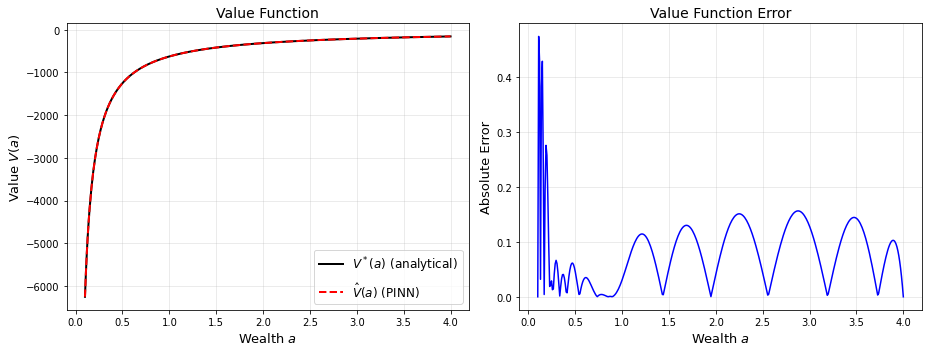

In [7]:
# ---------- evaluate on a fine grid ----------
N_eval = 400
a_eval = torch.linspace(a_min, a_max, N_eval, device=device, dtype=dtype).unsqueeze(1)

with torch.no_grad():
    V_hat = model(a_eval).cpu().numpy().flatten()

a_np    = a_eval.cpu().numpy().flatten()
V_exact = np.array([V_star(ai) for ai in a_np])

mse_V = np.mean((V_hat - V_exact) ** 2)
print(f"Value function MSE: {mse_V:.3e}")

# ---------- plot ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(a_np, V_exact, "k-", lw=2, label=r"$V^*(a)$ (analytical)")
axes[0].plot(a_np, V_hat, "r--", lw=2, label=r"$\hat{V}(a)$ (PINN)")
axes[0].set_xlabel(r"Wealth $a$", fontsize=13)
axes[0].set_ylabel("Value $V(a)$", fontsize=13)
axes[0].set_title("Value Function", fontsize=14)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(a_np, np.abs(V_hat - V_exact), "b-", lw=1.5)
axes[1].set_xlabel(r"Wealth $a$", fontsize=13)
axes[1].set_ylabel("Absolute Error", fontsize=13)
axes[1].set_title("Value Function Error", fontsize=14)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

# ----- Final V-MSE assertion (mode-dependent) -----
_tol_V = {"smoke": float("inf"), "teaching": 1e-3, "production": 1e-4}[RUN_MODE]
assert mse_V < _tol_V, f"Value-fn MSE {mse_V:.2e} exceeds tol {_tol_V:.0e} for RUN_MODE={RUN_MODE!r}"
print(f"\u2713 V-MSE {mse_V:.2e} < {_tol_V:.0e}")


## Results: Consumption Policy

Consumption policy max absolute error: 4.237e-03
Consumption policy relative L2 error: 6.363e-03


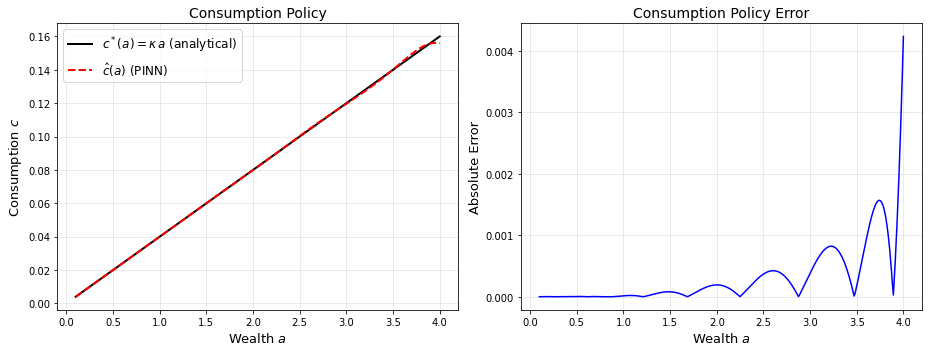

In [8]:

# ---------- recover consumption policy from trained V ----------
a_policy = torch.linspace(a_min, a_max, N_eval, device=device, dtype=dtype).unsqueeze(1)
a_policy.requires_grad_(True)

V_policy = model(a_policy)
V_a_policy = autograd.grad(
    outputs=V_policy, inputs=a_policy,
    grad_outputs=torch.ones_like(V_policy),
    create_graph=False
)[0]

safe_Va_policy = nn.functional.softplus(V_a_policy) + 1e-6  # matches script/deck \varepsilon
c_hat = (safe_Va_policy ** (-1.0 / gamma)).detach().cpu().numpy().flatten()

c_exact = np.array([c_star(ai) for ai in a_np])
max_err_c = np.max(np.abs(c_hat - c_exact))
rel_l2_c = np.sqrt(np.mean((c_hat - c_exact) ** 2)) / (np.sqrt(np.mean(c_exact ** 2)) + 1e-12)
print(f"Consumption policy max absolute error: {max_err_c:.3e}")
print(f"Consumption policy relative L2 error: {rel_l2_c:.3e}")

# ---------- plot ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(a_np, c_exact, "k-", lw=2, label=r"$c^*(a)=\kappa\,a$ (analytical)")
axes[0].plot(a_np, c_hat, "r--", lw=2, label=r"$\hat{c}(a)$ (PINN)")
axes[0].set_xlabel(r"Wealth $a$", fontsize=13)
axes[0].set_ylabel(r"Consumption $c$", fontsize=13)
axes[0].set_title("Consumption Policy", fontsize=14)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(a_np, np.abs(c_hat - c_exact), "b-", lw=1.5)
axes[1].set_xlabel(r"Wealth $a$", fontsize=13)
axes[1].set_ylabel("Absolute Error", fontsize=13)
axes[1].set_title("Consumption Policy Error", fontsize=14)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

# ----- Final c-policy assertion (mode-dependent rel-L2) -----
_tol_c = {"smoke": float("inf"), "teaching": 5e-3, "production": 1e-3}[RUN_MODE]
assert rel_l2_c < _tol_c, f"c-policy rel-L2 {rel_l2_c:.2e} exceeds tol {_tol_c:.0e} for RUN_MODE={RUN_MODE!r}"
print(f"\u2713 c-policy rel-L2 {rel_l2_c:.2e} < {_tol_c:.0e}")


## Takeaway and Discussion

The hard-boundary trial-solution PINN accurately recovers both the value function $V(a)$ and the
consumption policy $c(a)$ for the cake-eating problem.  Key observations:

* **The PDE residual serves as an unsupervised loss.**  We only supplied boundary values;
  the network learned the interior solution by satisfying the HJB equation.
* **The softplus safeguard is essential.**  Without it, early iterates produce negative $V'(a)$
  and the FOC inversion $c=(V')^{-1/\gamma}$ yields NaN.  Softplus is smooth and
  gradient-friendly, making it preferable to hard clipping.
* **DGM is useful, but not needed here.**  For this one-dimensional benchmark, the compact
  trial-solution MLP is easier to train because the endpoints are exact and no soft boundary
  penalty competes with the interior HJB residual. DGM remains useful as an optional heavier
  architecture for higher-dimensional or sharper PDEs.

### Extensions

The same methodology extends naturally to richer economic models:

* **Income risk (Merton problem):** Add a diffusion term $\sigma\,a\,dW_t$ to the wealth
  dynamics.  The HJB becomes a second-order PDE and requires an additional $V''(a)$ term
  in the residual.
* **Aiyagari / Huggett models:** Solve the stationary distribution jointly with the HJB
  by adding a Kolmogorov Forward Equation (KFE) loss.
* **General equilibrium:** Prices (e.g. the interest rate $r$) become endogenous and must
  clear markets.  A PINN can enforce both the HJB and the market-clearing condition
  simultaneously, scaling to problems where traditional grid methods are infeasible.